In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

val_df = pd.read_csv(
    "../data/processed/validation_processed.csv"
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (68976, 3)
Validation: (8878, 3)


In [3]:
X_train = train_df["clean_text"]
y_train = train_df["labels"]

X_val = val_df["clean_text"]
y_val = val_df["labels"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (68976,)
y_train: (68976,)
X_val: (8878,)
y_val: (8878,)


In [4]:
tfidf_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.joblib"
)

print("TF-IDF vectorizer loaded!")

TF-IDF vectorizer loaded!


In [5]:
X_train_tfidf = tfidf_vectorizer.transform(
    X_train
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val
)

print(
    "Train TF-IDF:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF:",
    X_val_tfidf.shape
)

Train TF-IDF: (68976, 100000)
Validation TF-IDF: (8878, 100000)


In [6]:
nb_model = MultinomialNB(
    alpha=1.0
)

In [7]:
nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed!")

Training completed!


In [9]:
y_val_pred = nb_model.predict(
    X_val_tfidf
)
comparison = pd.DataFrame({
    "Actual": y_val.iloc[:10].values,
    "Predicted": y_val_pred[:10]
})

comparison

,Actual,Predicted
0,nl,nl
1,nl,nl
2,es,es
3,it,it
4,ar,ar
5,ru,ru
6,tr,tr
7,nl,nl
8,fr,fr
9,es,es


In [10]:
accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.9934


In [13]:
precision_macro = precision_score(
    y_val,
    y_val_pred,
    average="macro"
)

recall_macro = recall_score(
    y_val,
    y_val_pred,
    average="macro"
)

f1_macro = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_val,
    y_val_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_val,
    y_val_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_val,
    y_val_pred,
    average="weighted"
)
print("=== Multinomial Naive Bayes ===")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1-score:     {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1-score:  {f1_weighted:.4f}")

=== Multinomial Naive Bayes ===
Accuracy:           0.9934
Macro Precision:    0.9935
Macro Recall:       0.9930
Macro F1-score:     0.9932
Weighted Precision: 0.9935
Weighted Recall:    0.9934
Weighted F1-score:  0.9933


In [14]:
print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

          ar     1.0000    0.9975    0.9988       402
          bg     0.9950    1.0000    0.9975       402
          de     0.9940    1.0000    0.9970       500
          el     1.0000    1.0000    1.0000       402
          en     0.9804    1.0000    0.9901       499
          es     0.9843    1.0000    0.9921       500
          fr     0.9960    1.0000    0.9980       497
          hi     1.0000    0.9428    0.9706       402
          it     0.9979    0.9957    0.9968       468
          ja     1.0000    0.9980    0.9990       500
          nl     0.9872    0.9978    0.9925       463
          pl     1.0000    0.9978    0.9989       463
          pt     1.0000    0.9808    0.9903       469
          ru     1.0000    0.9950    0.9975       402
          sw     0.9459    1.0000    0.9722       402
          th     1.0000    0.9925    0.9963       402
          tr     0.9901    1.0000    0.9950       402
          ur     1.0000    

In [15]:
report = classification_report(
    y_val,
    y_val_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
ar,1.000000,0.997512,0.998755,402.000000
bg,0.995050,1.000000,0.997519,402.000000
de,0.994036,1.000000,0.997009,500.000000
el,1.000000,1.000000,1.000000,402.000000
en,0.980354,1.000000,0.990079,499.000000
es,0.984252,1.000000,0.992063,500.000000
fr,0.995992,1.000000,0.997992,497.000000
hi,1.000000,0.942786,0.970551,402.000000
it,0.997859,0.995726,0.996791,468.000000
ja,1.000000,0.998000,0.998999,500.000000


In [16]:
language_report = report_df.loc[
    sorted(y_val.unique())
]

language_report.sort_values(
    by="f1-score"
).head(10)

,precision,recall,f1-score,support
hi,1.000000,0.942786,0.970551,402.0
sw,0.945882,1.000000,0.972189,402.0
ur,1.000000,0.967662,0.983565,402.0
en,0.980354,1.000000,0.990079,499.0
pt,1.000000,0.980810,0.990312,469.0
es,0.984252,1.000000,0.992063,500.0
nl,0.987179,0.997840,0.992481,463.0
tr,0.990148,1.000000,0.995050,402.0
th,1.000000,0.992537,0.996255,402.0
it,0.997859,0.995726,0.996791,468.0


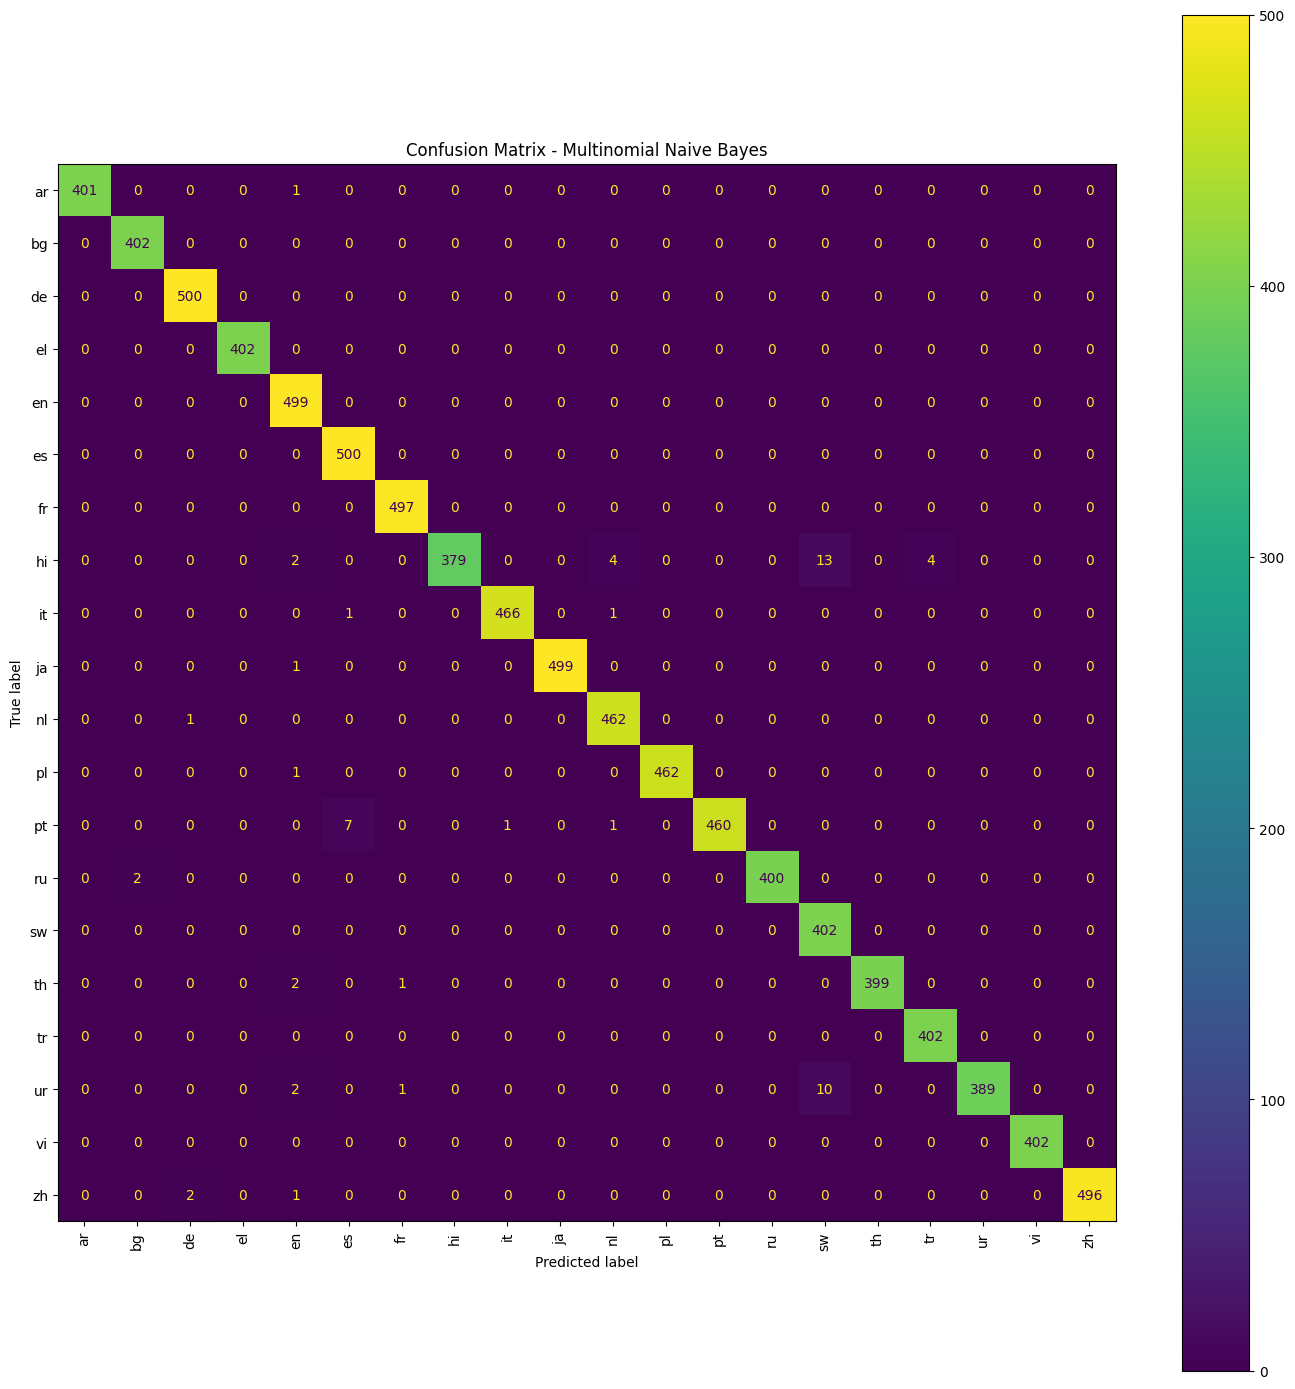

In [17]:
labels = sorted(y_val.unique())

fig, ax = plt.subplots(
    figsize=(14, 14)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    labels=labels,
    display_labels=labels,
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - Multinomial Naive Bayes"
)

plt.tight_layout()
plt.show()

In [18]:
wrong_predictions = val_df.copy()

wrong_predictions["predicted"] = y_val_pred

wrong_predictions = wrong_predictions[
    wrong_predictions["labels"]
    != wrong_predictions["predicted"]
]

print(
    "Số mẫu dự đoán sai:",
    len(wrong_predictions)
)

wrong_predictions[
    [
        "labels",
        "predicted",
        "clean_text"
    ]
].head(20)

Số mẫu dự đoán sai: 59


,labels,predicted,clean_text
111,zh,en,这质量只怕还不如仿货，还made in Italy ，妥妥打脸
119,ar,en,Umeda marks the northern end of the business a...
138,ja,en,13インチ Core i5 8G 480GB Microsoft office付き 1.2K...
212,pt,es,Um método utilizado para calcular a distância ...
517,ur,fr,State ko techinal functions outsource karne ka...
576,th,fr,ดูที่ทาง Passeig de Gracia จนจรดตะวันออก โดยเฉ...
720,pt,nl,A actriz 'Desperate Housewives' Kathryn Jooste...
760,hi,nl,nahi. Blood ne uske telescope ko band kar diya.
1029,hi,nl,Maennerchor Society star par varshik nidhi ke ...
1097,ru,bg,"Посмотрите на Пасеч де Грасия на восток, особе..."


In [20]:
correct = (
    y_val.values == y_val_pred
).sum()

incorrect = (
    y_val.values != y_val_pred
).sum()

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Total:", len(y_val))
print(
    "Accuracy check:",
    correct / len(y_val)
)

Correct: 8819
Incorrect: 59
Total: 8878
Accuracy check: 0.9933543590898851


In [22]:
os.makedirs(
    "../outputs/results",
    exist_ok=True
)
nb_results = pd.DataFrame({
    "model": [
        "Multinomial Naive Bayes"
    ],
    "accuracy": [
        accuracy
    ],
    "precision_macro": [
        precision_macro
    ],
    "recall_macro": [
        recall_macro
    ],
    "f1_macro": [
        f1_macro
    ],
    "precision_weighted": [
        precision_weighted
    ],
    "recall_weighted": [
        recall_weighted
    ],
    "f1_weighted": [
        f1_weighted
    ]
})

nb_results

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Multinomial Naive Bayes,0.993354,0.993538,0.992986,0.993151,0.993546,0.993354,0.993347


In [23]:
nb_results.to_csv(
    "../outputs/results/experiment_1_naive_bayes.csv",
    index=False
)

print("Experiment results saved!")

Experiment results saved!


In [24]:
joblib.dump(
    nb_model,
    "../models/naive_bayes_model.joblib"
)

print("Naive Bayes model saved!")

Naive Bayes model saved!


In [25]:
loaded_nb_model = joblib.load(
    "../models/naive_bayes_model.joblib"
)

print("Model loaded!")

Model loaded!


In [26]:
sample_text = [
    "Bonjour, comment allez-vous?"
]

sample_vector = tfidf_vectorizer.transform(
    sample_text
)

prediction = loaded_nb_model.predict(
    sample_vector
)

print(
    "Predicted language:",
    prediction[0]
)

Predicted language: fr


In [27]:
samples = [
    "Hello, how are you today?",
    "Bonjour, comment allez-vous?",
    "Xin chào, hôm nay bạn khỏe không?",
    "¿Cómo estás hoy?",
    "これは日本語の文章です。",
    "这是一个中文句子。"
]

sample_vectors = tfidf_vectorizer.transform(
    samples
)

predictions = loaded_nb_model.predict(
    sample_vectors
)

for text, language in zip(
    samples,
    predictions
):
    print(
        f"{language:>3} | {text}"
    )

 en | Hello, how are you today?
 fr | Bonjour, comment allez-vous?
 vi | Xin chào, hôm nay bạn khỏe không?
 es | ¿Cómo estás hoy?
 ja | これは日本語の文章です。
 zh | 这是一个中文句子。


## Kết luận

- Multinomial Naive Bayes được sử dụng làm mô hình thử nghiệm đầu tiên cho bài toán nhận diện ngôn ngữ văn bản.
- Mô hình được huấn luyện trên đặc trưng TF-IDF kết hợp Character N-gram đã xây dựng ở bước trước.
- Hiệu suất của mô hình được đánh giá trên tập validation bằng các chỉ số Accuracy, Precision, Recall và F1-score.
- Classification Report và Confusion Matrix được sử dụng để phân tích hiệu quả nhận diện đối với từng ngôn ngữ.
- Các mẫu dự đoán sai được kiểm tra nhằm xác định những nhóm ngôn ngữ mà mô hình dễ nhầm lẫn.
- Kết quả của thử nghiệm được lưu lại để so sánh với Logistic Regression và Linear SVM trong các thử nghiệm tiếp theo.
- Tập test chưa được sử dụng ở giai đoạn này và sẽ chỉ được dùng để đánh giá mô hình cuối cùng sau khi hoàn tất quá trình lựa chọn mô hình.